In [1]:
import pandas as pd
import os
from pathlib import Path
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns   

plt.style.use("ggplot")

In [2]:
os.getcwd()

'/home/jterryc/KOMOREBI-PROJECT/src'

In [3]:
os.listdir(".")

['src.txt', 'EDA.md', 'EDA.ipynb', 'EDA_files']

In [4]:
wd_local_path = '../data/zrive_advertiser_withdrawals.parquet'
dim_local_path = '../data/zrive_dim_advertiser.parquet'
fct_local_path = '../data/zrive_fct_monthly_snapshot_advertiser.parquet'

In [5]:
df_wd = pd.read_parquet(wd_local_path, engine='fastparquet')
df_dim = pd.read_parquet(dim_local_path, engine='fastparquet')
df_fct = pd.read_parquet(fct_local_path, engine='fastparquet')

<h4>1. Información General de los datos (DF_DIM)<h4>

><h4> 1.1 Análisis del df</h4>

In [6]:
print(f"Forma: {df_dim.shape}")
print(f"\nColumnas:")
print(df_dim.columns.tolist())
print(f"\nTipos de datos:")
print(df_dim.dtypes)

Forma: (7076, 8)

Columnas:
['advertiser_zrive_id', 'province_id', 'updated_at', 'advertiser_province', 'advertiser_group_id', 'min_start_contrato_date', 'max_start_contrato_nuevo_date', 'contrato_churn_date']

Tipos de datos:
advertiser_zrive_id                       int64
province_id                               int64
updated_at                       datetime64[us]
advertiser_province                      object
advertiser_group_id                     float64
min_start_contrato_date          datetime64[ns]
max_start_contrato_nuevo_date    datetime64[ns]
contrato_churn_date              datetime64[ns]
dtype: object


In [7]:
df_dim.head()

,advertiser_zrive_id,province_id,updated_at,advertiser_province,advertiser_group_id,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date
0,986,1,2025-05-01 02:46:04,Álava,194.0,2025-01-07,2025-01-07,2025-05-17
1,6811,1,2025-02-05 01:02:08,Álava,NaN,2025-01-24,NaT,2025-02-04
2,4890,2,2024-08-09 13:38:43,Albacete,133.0,2023-02-24,NaT,2023-06-03
3,3428,3,2023-11-02 13:51:07,Alicante,NaN,2023-03-17,2023-03-17,2023-11-01
4,547,3,2024-02-05 13:49:02,Alicante,NaN,2023-05-03,NaT,2023-12-29


In [8]:
df_dim["updated_at"].max()

Timestamp('2025-06-19 18:36:05')

In [9]:
df_dim["advertiser_zrive_id"].is_unique

True

En **df_dim**, tenemos 1 fila = 1 advertiser

><h4> 1.2 Análisis por provincia</h4>

In [10]:
#Sumauto aplica descuentos por provincias porque no todas generan el mismo tráfico
advertiser_province_unique = df_dim["advertiser_province"].unique()
print(f"Provincias unicas:  {advertiser_province_unique}")

advertiser_province_nunique = df_dim["advertiser_province"].nunique()
print(f"Num Provincias unicas: {advertiser_province_nunique}")

Provincias unicas:  ['Álava' 'Albacete' 'Alicante' 'Asturias' 'Badajoz' 'Barcelona' 'Burgos'
 'Cáceres' 'Cantabria' 'Castellón' 'Córdoba' 'La Coruña' 'Girona'
 'Granada' 'Guadalajara' 'Huesca' 'Islas Baleares' 'Jaén' 'Lugo' 'Madrid'
 'Málaga' 'Murcia' 'Navarra' 'Pontevedra' 'La Rioja' 'Segovia' 'Sevilla'
 'Teruel' 'Toledo' 'Valencia' 'Valladolid' 'Vizcaya' 'Zaragoza' 'Almería'
 'Ávila' 'Cádiz' 'Ciudad Real' 'Cuenca' 'Guipúzcoa' 'Huelva' 'León'
 'Lleida' 'Orense' 'Palencia' 'Las Palmas' 'Salamanca' 'Soria' 'Tarragona'
 'Tenerife' 'Zamora' 'Ceuta' 'Melilla']
Num Provincias unicas: 52


In [11]:
#top 15 provincias
top_provinces = df_dim['advertiser_province'].value_counts(normalize=True).head(15)
print(top_provinces)

#Porcentaje acumulado (Top5)
total_clients = len(df_dim)
top5= top_provinces.head(5).sum()*100
print(f"Top 5 provincias concentran {top5:.2f}% de los cientes")

advertiser_province
Madrid       0.169305
Barcelona    0.111504
Valencia     0.062041
Málaga       0.052855
Alicante     0.051018
Sevilla      0.048332
Murcia       0.036320
Asturias     0.024449
Toledo       0.022894
Vizcaya      0.022753
La Coruña    0.021057
Tarragona    0.020774
Granada      0.019927
Córdoba      0.018796
Zaragoza     0.016959
Name: proportion, dtype: float64
Top 5 provincias concentran 44.67% de los cientes


- Concentración geográfica muy alta. Top 5 provincias concentran 44.67% de los cientes (la mayoría del negocio está en grandes ciudades)
- No tendría sentido comparar directamente un cliente de Madrid o Barcelona con uno de Soria. 

><h4> 1.3 Análisis por grupos (concesionarios)</h4>

Clientes que pertenecen a un grupo: 1323 (18.70%)
Clientes independientes: 5753
Grupos únicos: 112
Distribución del tamaño de grupos:
count    112.000000
mean      11.812500
std       31.438924
min        1.000000
25%        2.000000
50%        4.000000
75%       11.000000
max      257.000000
dtype: float64

Top 10 grupos más grandes:
advertiser_group_id
125.0    257
55.0     195
48.0      78
117.0     69
100.0     49
41.0      29
68.0      22
58.0      22
132.0     22
154.0     22
dtype: int64


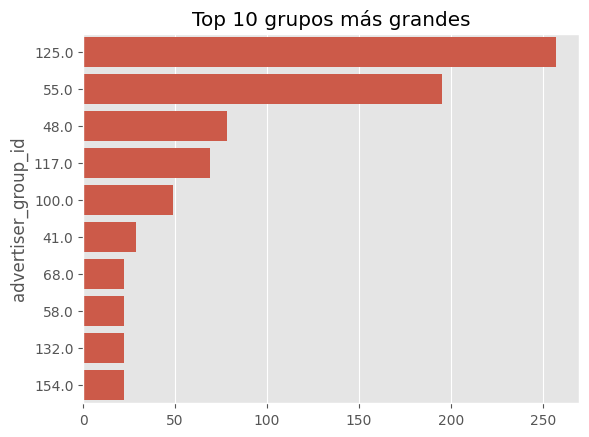

In [12]:
#Grupo de concesionarios (adv_group_id)
clients_in_group = df_dim['advertiser_group_id'].notna().sum()
pct_in_group = (clients_in_group / len(df_dim)) * 100

print(f"Clientes que pertenecen a un grupo: {clients_in_group} ({pct_in_group:.2f}%)")
print(f"Clientes independientes: {df_dim['advertiser_group_id'].isna().sum()}")

n_groups = df_dim['advertiser_group_id'].nunique()
print(f"Grupos únicos: {n_groups}")

# Tamaño promedio de los grupos
group_sizes = df_dim.groupby('advertiser_group_id').size()
print("Distribución del tamaño de grupos:")
print(group_sizes.describe())
print()
print("Top 10 grupos más grandes:")
print(group_sizes.sort_values(ascending=False).head(10))

advertiser_groups = (
    df_dim
    .groupby("advertiser_group_id")["advertiser_zrive_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

sns.barplot(
    x=advertiser_groups.values,
    y=advertiser_groups.index,
    order=advertiser_groups.index,
    orient = "h"
)
plt.title("Top 10 grupos más grandes")
plt.show()

In [13]:
# 1. Investigar grupo 125
top_group = df_dim[df_dim['advertiser_group_id'] == 125.0]
print(f"Provincias únicas del grupo 125: {top_group['advertiser_province'].nunique()}")
print("\nTop 10 provincias del grupo 125:")
print(top_group['advertiser_province'].value_counts().head(10))

Provincias únicas del grupo 125: 43

Top 10 provincias del grupo 125:
advertiser_province
Madrid       40
Barcelona    37
Alicante     13
Málaga       12
Vizcaya      11
Sevilla      10
Valencia      9
Granada       7
Toledo        6
Murcia        6
Name: count, dtype: int64


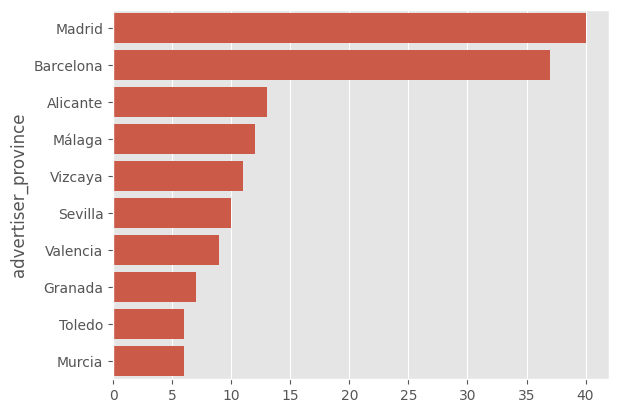

In [14]:
top10 = (
    top_group["advertiser_province"]
    .value_counts()
    .head(10)
)

sns.barplot(
    x=top10.values,
    y=top10.index,
    orient = "h"
)
plt.show()


- Solo el 18,70% de los clientes pertenece a un grupo, mientras que el resto son independientes.
- La mayoria de los grupos son pequeños (P50 = 4 clientes)
- El grupo más grande (125) es nacional, opera en 43 provincias de 52 provincias totales y además fuerte concentración en ciudades grandes (coincide que es donde más trafico de clientes hay)

<h4>2. Información General de los datos (DF_WITHDRAWAL)<h4>

In [15]:
df_wd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22668 entries, 0 to 22667
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   withdrawal_id              22668 non-null  int64         
 1   advertiser_zrive_id        22668 non-null  int64         
 2   withdrawal_status          22668 non-null  object        
 3   withdrawal_type            22668 non-null  object        
 4   withdrawal_creation_date   22668 non-null  datetime64[us]
 5   withdrawal_effective_date  14348 non-null  datetime64[ns]
 6   withdrawal_reason          22668 non-null  object        
dtypes: datetime64[ns](1), datetime64[us](1), int64(2), object(3)
memory usage: 1.2+ MB


In [16]:
df_wd.isna().sum()

withdrawal_id                   0
advertiser_zrive_id             0
withdrawal_status               0
withdrawal_type                 0
withdrawal_creation_date        0
withdrawal_effective_date    8320
withdrawal_reason               0
dtype: int64

In [17]:
print(f"Forma: {df_wd.shape}")
print(f"\nColumnas:")
print(df_wd.columns.tolist())
print(f"\nTipos de datos:")
print(df_wd.dtypes)

Forma: (22668, 7)

Columnas:
['withdrawal_id', 'advertiser_zrive_id', 'withdrawal_status', 'withdrawal_type', 'withdrawal_creation_date', 'withdrawal_effective_date', 'withdrawal_reason']

Tipos de datos:
withdrawal_id                         int64
advertiser_zrive_id                   int64
withdrawal_status                    object
withdrawal_type                      object
withdrawal_creation_date     datetime64[us]
withdrawal_effective_date    datetime64[ns]
withdrawal_reason                    object
dtype: object


In [18]:
df_wd['withdrawal_effective_date'] = pd.to_datetime(df_wd['withdrawal_effective_date'])
df_wd.head(10)

,withdrawal_id,advertiser_zrive_id,withdrawal_status,withdrawal_type,withdrawal_creation_date,withdrawal_effective_date,withdrawal_reason
0,0,259,Cerrada,TOTAL,2012-06-19 07:12:34,2012-07-01,RESULTADOS
1,1,221,Cerrada,TOTAL,2012-06-19 07:16:34,NaT,RESULTADOS
2,7,492,Cerrada,TOTAL,2012-06-20 07:10:16,2012-07-01,RESULTADOS
3,12,481,Cerrada,TOTAL,2012-06-20 11:59:36,2012-07-01,RESULTADOS
4,16,457,Cerrada,TOTAL,2012-06-20 15:41:39,2012-07-01,FALTA DE USO/TIEMPO
5,36,95,Cerrada,TOTAL,2012-06-22 10:40:37,2012-07-01,RAZONES ECONOMICAS
6,49,620,Cerrada,TOTAL,2012-06-26 15:53:04,NaT,RAZONES ECONOMICAS
7,53,443,Cerrada,TOTAL,2012-06-27 08:00:09,NaT,RESULTADOS
8,57,675,Cerrada,TOTAL,2012-06-27 10:55:17,2012-07-01,RESULTADOS
9,58,195,Cerrada,TOTAL,2012-06-27 11:19:15,2012-07-01,RESULTADOS


><h4>2.1 Análisis de Razones de Baja<h4>

Se consideran bajas definitivas aquellas donde: 
1. withdrawal_type = 'TOTAL' 
2. withdrawal_status != 'Denegada' 
3. withdrawal_reason not in ('Upselling-cambio de contrato', 'Cambio a Bundle Online', 
'Cambio de Contrato/propuesta/producto')

In [19]:
withdrawal_reason_not = ['Upselling-cambio de contrato', 'Cambio a Bundle Online','Cambio de Contrato/propuesta/producto']
withdrawal_reason_yes = set(df_wd.withdrawal_reason.values).difference(set(withdrawal_reason_not))
withdrawal_reason_yes

{'Baja Bundle AS24',
 'CESE DE ACTIVIDAD',
 'CORONAVIRUS',
 'Desconocido',
 'FALTA DE PRODUCTO',
 'FALTA DE USO/TIEMPO',
 'FIN DE CONTRATO',
 'Incidencias de la web',
 'MOROSIDAD',
 'No acepta subida',
 'OTROS',
 'RATIO RESULTADO-INVERSION',
 'RAZONES ECONOMICAS',
 'RESULTADOS',
 'Reestructuración cuentas de grupo'}

In [20]:
# Creamos nueva columna binaria para definir las filas con withdrawal definitivo
df_wd["is_definitive_withdrawal"] = (
    df_wd.withdrawal_reason.isin(withdrawal_reason_yes) &
    (df_wd.withdrawal_type == "TOTAL") &
    (df_wd.withdrawal_status != "Denegada")
).astype(int)
df_wd

,withdrawal_id,advertiser_zrive_id,withdrawal_status,withdrawal_type,withdrawal_creation_date,withdrawal_effective_date,withdrawal_reason,is_definitive_withdrawal
0,0,259,Cerrada,TOTAL,2012-06-19 07:12:34,2012-07-01,RESULTADOS,1
1,1,221,Cerrada,TOTAL,2012-06-19 07:16:34,NaT,RESULTADOS,1
2,7,492,Cerrada,TOTAL,2012-06-20 07:10:16,2012-07-01,RESULTADOS,1
3,12,481,Cerrada,TOTAL,2012-06-20 11:59:36,2012-07-01,RESULTADOS,1
4,16,457,Cerrada,TOTAL,2012-06-20 15:41:39,2012-07-01,FALTA DE USO/TIEMPO,1
...,...,...,...,...,...,...,...,...
22663,55613,684,Cerrada,TOTAL,2025-05-30 10:57:08,2025-08-01,RATIO RESULTADO-INVERSION,1
22664,55614,251,Cerrada,TOTAL,2025-05-30 10:58:12,2025-08-01,RATIO RESULTADO-INVERSION,1
22665,55615,80,Cerrada,TOTAL,2025-05-30 10:59:03,2025-08-01,RATIO RESULTADO-INVERSION,1
22666,55616,5149,Cerrada,TOTAL,2025-05-30 11:15:01,2025-07-01,MOROSIDAD,1


In [21]:
df_wd["advertiser_zrive_id"].value_counts()

advertiser_zrive_id
122     58
2915    47
1378    44
953     36
56      35
        ..
6927     1
6294     1
6409     1
6825     1
6922     1
Name: count, Length: 6021, dtype: int64

In [22]:
#Top 15 razones de baja (%)
reason_dist = (
    df_wd
    .loc[df_wd.is_definitive_withdrawal == 1, "withdrawal_reason"]
    .value_counts(normalize=True)
    .head(15)
) *100
print(round(reason_dist, 2))


withdrawal_reason
RESULTADOS                           36.14
MOROSIDAD                            19.94
RAZONES ECONOMICAS                   14.06
RATIO RESULTADO-INVERSION            10.16
FALTA DE USO/TIEMPO                   5.34
OTROS                                 4.50
FALTA DE PRODUCTO                     3.59
CESE DE ACTIVIDAD                     2.86
Reestructuración cuentas de grupo     1.15
FIN DE CONTRATO                       0.90
CORONAVIRUS                           0.63
No acepta subida                      0.32
Desconocido                           0.23
Incidencias de la web                 0.13
Baja Bundle AS24                      0.04
Name: proportion, dtype: float64


>La principal causa de baja está relacionada con los resultados, junto con razones economicas y morosidad suma mas del 60%, lo que indica que el churn está muy relacionado con la retorno del servicio

<h4>3. Información General de los datos (DF_FCT)<h4>

In [23]:
df_fct.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96829 entries, 0 to 96828
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   advertiser_zrive_id            96829 non-null  int64  
 1   period_int                     96829 non-null  int64  
 2   monthly_contracted_ads         96829 non-null  int64  
 3   monthly_published_ads          96829 non-null  int64  
 4   monthly_unique_published_ads   96829 non-null  int64  
 5   monthly_distinct_ads           86777 non-null  float64
 6   monthly_oro_ads                96829 non-null  int64  
 7   monthly_plata_ads              96829 non-null  int64  
 8   monthly_destacados_ads         96829 non-null  int64  
 9   monthly_pepitas_ads            96829 non-null  int64  
 10  monthly_shows                  96829 non-null  float64
 11  monthly_visits                 96829 non-null  float64
 12  monthly_leads                  96829 non-null 

In [24]:
df_fct[["advertiser_zrive_id", "period_int"]].duplicated().any()

np.False_

Tabla **df_fct**: 1 fila = 1 mes

In [25]:
print(f"Forma: {df_fct.shape}")
print(f"\nColumnas:")
print(df_fct.columns.tolist())


Forma: (96829, 23)

Columnas:
['advertiser_zrive_id', 'period_int', 'monthly_contracted_ads', 'monthly_published_ads', 'monthly_unique_published_ads', 'monthly_distinct_ads', 'monthly_oro_ads', 'monthly_plata_ads', 'monthly_destacados_ads', 'monthly_pepitas_ads', 'monthly_shows', 'monthly_visits', 'monthly_leads', 'monthly_total_phone_views', 'monthly_total_calls', 'monthly_total_emails', 'monthly_total_invoice', 'monthly_total_reference_price', 'monthly_unique_calls', 'monthly_unique_emails', 'monthly_unique_leads', 'monthly_avg_ad_price', 'has_active_contract']


In [26]:
(df_fct < 0).any()

advertiser_zrive_id              False
period_int                       False
monthly_contracted_ads           False
monthly_published_ads            False
monthly_unique_published_ads     False
monthly_distinct_ads             False
monthly_oro_ads                  False
monthly_plata_ads                False
monthly_destacados_ads           False
monthly_pepitas_ads              False
monthly_shows                    False
monthly_visits                   False
monthly_leads                    False
monthly_total_phone_views        False
monthly_total_calls              False
monthly_total_emails             False
monthly_total_invoice             True
monthly_total_reference_price    False
monthly_unique_calls             False
monthly_unique_emails            False
monthly_unique_leads             False
monthly_avg_ad_price             False
has_active_contract              False
dtype: bool

In [27]:
df_fct = pd.read_parquet(fct_local_path, engine='fastparquet')
df_fct[df_fct["monthly_total_invoice"] < 0]

,advertiser_zrive_id,period_int,monthly_contracted_ads,monthly_published_ads,monthly_unique_published_ads,monthly_distinct_ads,monthly_oro_ads,monthly_plata_ads,monthly_destacados_ads,monthly_pepitas_ads,...,monthly_total_phone_views,monthly_total_calls,monthly_total_emails,monthly_total_invoice,monthly_total_reference_price,monthly_unique_calls,monthly_unique_emails,monthly_unique_leads,monthly_avg_ad_price,has_active_contract
49074,5242,202403,20,19,19,17.0,2,2,1,0,...,1,0,0,-130.6,693.3,0,0,0,22405.88,True
84780,2260,202502,1000,996,996,1049.0,6,6,6,0,...,57,18,16,-1833.3,NaN,15,51,66,309080.72,True


- Aparecen dos registros negativos en monthly_total_invoice. Al ser casos muy concretos y no representar el comportamiento normal de facturación, tiene sentido excluirlos del análisis para no distorsionar la distribución.

In [28]:
df_fct = df_fct[df_fct["monthly_total_invoice"] >= 0].copy()

- Para el análisis de pricing solo se tienen en cuenta los meses con contrato activo (has_active_contract = True).
Los meses sin contrato tienen facturación 0 y precios de referencia nulos, por lo que no aportan información útil sobre el valor real del cliente y distorsionan las métricas.

In [29]:
# Miramos si hay usuarios con has_active_contract = 0 en el periodo de estudio (2023 - 2025)
(
    df_fct
    .groupby("advertiser_zrive_id")["has_active_contract"]
    .sum()
    .loc[lambda x: x==0]
)

advertiser_zrive_id
7036    0
7066    0
7069    0
Name: has_active_contract, dtype: int64

Los usuarios 7036, 7066 y 7069 no tuvieron ningún contrato activo en el periodo de estudio, por lo que los excluímos del análisis

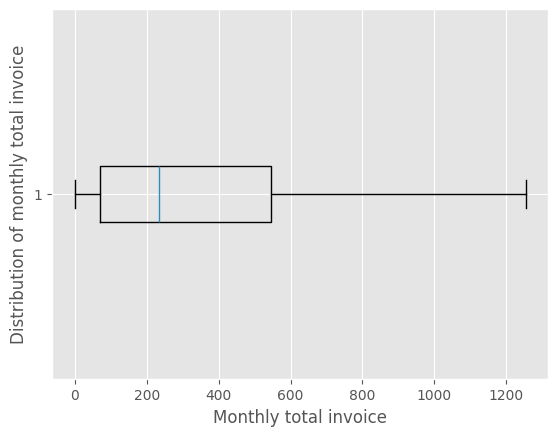

In [30]:
plt.figure()
plt.boxplot(df_fct["monthly_total_invoice"], vert = False, showfliers= False)
plt.xlabel("Monthly total invoice")
plt.ylabel("Distribution of monthly total invoice")
plt.show()

><h4> Permanencia Clientes<h4>

Analizamos los datos temporales en **df_fct**, que es la información sobre la actividad de los df_dim en el periodo de estudio (2023-2025)

In [31]:
# Convertimos la columna "period_int" a YYYY-MM-DD
try:
    df_fct["period_int"] = pd.to_datetime(df_fct["period_int"].astype(str), format="%Y%m").dt.to_period("M")
except ValueError:
    pass
df_fct.head()

,advertiser_zrive_id,period_int,monthly_contracted_ads,monthly_published_ads,monthly_unique_published_ads,monthly_distinct_ads,monthly_oro_ads,monthly_plata_ads,monthly_destacados_ads,monthly_pepitas_ads,...,monthly_total_phone_views,monthly_total_calls,monthly_total_emails,monthly_total_invoice,monthly_total_reference_price,monthly_unique_calls,monthly_unique_emails,monthly_unique_leads,monthly_avg_ad_price,has_active_contract
0,1,2023-01,75,47,47,56.0,6,6,6,0,...,14,15,0,1714.2,2416.7,12,3,15,42667.86,True
1,2,2023-01,150,31,31,55.0,10,10,4,0,...,16,2,2,293.3,3643.3,2,2,4,22742.40,True
2,3,2023-01,0,0,0,NaN,0,0,0,0,...,0,0,0,0.0,NaN,0,0,0,25420.83,False
3,4,2023-01,85,79,79,86.0,3,3,1,0,...,10,8,2,1165.0,3023.3,6,6,12,23259.52,True
4,6,2023-01,20,20,20,25.0,0,0,1,0,...,10,4,3,336.3,515.0,4,11,15,43439.00,True


In [32]:
df_fct[df_fct["advertiser_zrive_id"]==16]

,advertiser_zrive_id,period_int,monthly_contracted_ads,monthly_published_ads,monthly_unique_published_ads,monthly_distinct_ads,monthly_oro_ads,monthly_plata_ads,monthly_destacados_ads,monthly_pepitas_ads,...,monthly_total_phone_views,monthly_total_calls,monthly_total_emails,monthly_total_invoice,monthly_total_reference_price,monthly_unique_calls,monthly_unique_emails,monthly_unique_leads,monthly_avg_ad_price,has_active_contract
10,16,2023-01,75,20,20,78.0,6,6,6,0,...,29,18,6,1329.1,3180.0,16,10,26,22120.16,True
3551,16,2023-02,75,30,30,94.0,6,6,6,0,...,30,24,9,730.0,2210.0,21,22,43,22509.08,True
6914,16,2023-03,75,59,59,152.0,6,6,6,0,...,23,19,6,730.0,2210.0,16,23,39,23040.26,True
10337,16,2023-04,75,37,37,110.0,6,6,6,0,...,29,45,9,730.0,2210.0,21,24,45,22711.89,True
13757,16,2023-05,75,58,58,134.0,6,6,6,0,...,22,14,5,730.0,2210.0,11,13,24,23576.57,True
17146,16,2023-06,75,81,81,170.0,6,6,6,0,...,19,10,6,730.0,2210.0,9,13,22,23734.82,True
20507,16,2023-07,75,72,72,182.0,6,6,6,0,...,18,10,8,730.0,2210.0,9,15,24,23482.54,True
23946,16,2023-08,75,65,65,139.0,6,6,6,0,...,35,27,13,730.0,2210.0,21,20,41,25109.20,True
27169,16,2023-09,75,50,50,111.0,6,6,6,0,...,8,11,6,730.0,2210.0,10,8,18,24902.29,True
30369,16,2023-10,75,62,62,113.0,6,6,6,0,...,22,14,3,730.0,2210.0,11,7,18,25592.64,True


In [33]:
df_months = (
    df_fct
    .groupby("advertiser_zrive_id")["period_int"]
    .nunique()
    .reset_index()
    .rename(columns={"period_int":"n_months"})
)

print(df_months["n_months"].describe())

count    6968.000000
mean       13.895953
std         9.970284
min         1.000000
25%         5.000000
50%        11.000000
75%        25.000000
max        29.000000
Name: n_months, dtype: float64


Text(0, 0.5, 'Anunciantes')

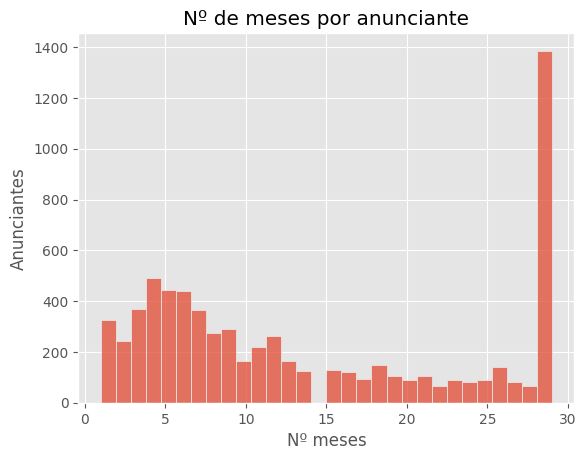

In [34]:
sns.histplot(df_months, x="n_months", bins=30)

plt.title("Nº de meses por anunciante")
plt.xlabel("Nº meses")
plt.ylabel("Anunciantes")

Distribución bimodal; podemos comprobar que los df_fct se concentran en dos grupos principales:
- Corto-medio plazo (5 meses aprox.)
- Largo plazo (29 meses aprox.)

count      29.000000
mean     3338.862069
std       100.918186
min      3144.000000
25%      3258.000000
50%      3346.000000
75%      3413.000000
max      3542.000000
Name: n_active_users, dtype: float64

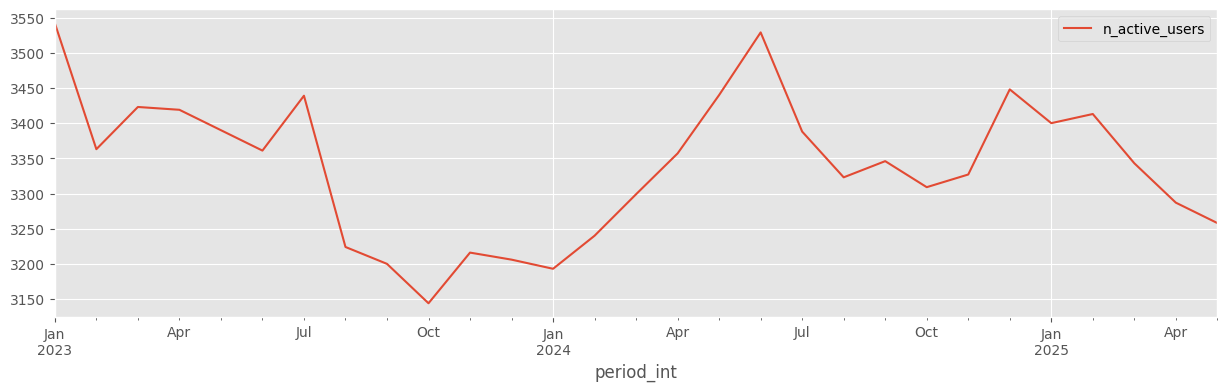

In [35]:
active_users_month = (
    df_fct
    .groupby("period_int")["advertiser_zrive_id"]
    .nunique()
    .reset_index()
    .rename(columns={"advertiser_zrive_id":"n_active_users"})
)

active_users_month.plot(
    x="period_int",
    y="n_active_users",
    kind="line",
    figsize=(15,4)
)
active_users_month["n_active_users"].describe()

In [36]:
cv = active_users_month["n_active_users"].std()/active_users_month["n_active_users"].mean()
print(f"Coeficiente de variación: {cv:.2f}")

Coeficiente de variación: 0.03


- La media de advertisers activos por mes es 3339, con CV=3%, lo que representa poca variación en el periodo de estudio

In [37]:
df_fct["price_bucket"] = pd.cut(
    df_fct["monthly_total_invoice"],
    bins=[0, 100, 250, 500, 1000, 5000, 40000],
    labels=["<100", "100-250", "250-500", "500-1k", "1k-5k", "5k+"]
)

df_fct["price_bucket"].value_counts(normalize=True).sort_index()

price_bucket
<100       0.231605
100-250    0.241092
250-500    0.233906
500-1k     0.168397
1k-5k      0.112941
5k+        0.012059
Name: proportion, dtype: float64

In [38]:
df_fct["price_diff_pct"] = (
    df_fct["monthly_total_invoice"]
    / df_fct["monthly_total_reference_price"]
) - 1
df_fct["price_diff_pct"].describe()


count    84498.000000
mean        -0.483692
std          0.677025
min         -1.000000
25%         -0.702794
50%         -0.500000
75%         -0.229515
max        125.640769
Name: price_diff_pct, dtype: float64

- La mayor parte de los clientes se concentra en un rango de precio mensual bajo: cerca del 70% paga menos de 500€, con un peso muy relevante entre 100–250€ y 250–500€. 
- Al comprarar el precio de tarifa frente a la facturación mensual, los clientes pagan significativamente menos del precio de tarifa (-50%), esto significa que el precio tarifa está mal planteado

In [39]:
df_fct["monthly_contracted_ads"].quantile(0.95)

np.float64(300.0)

In [40]:
df_fct["monthly_contracted_ads"].describe(percentiles=[0.95])

count    96827.000000
mean       108.101191
std        490.209838
min          0.000000
50%         20.000000
95%        300.000000
max       8200.000000
Name: monthly_contracted_ads, dtype: float64

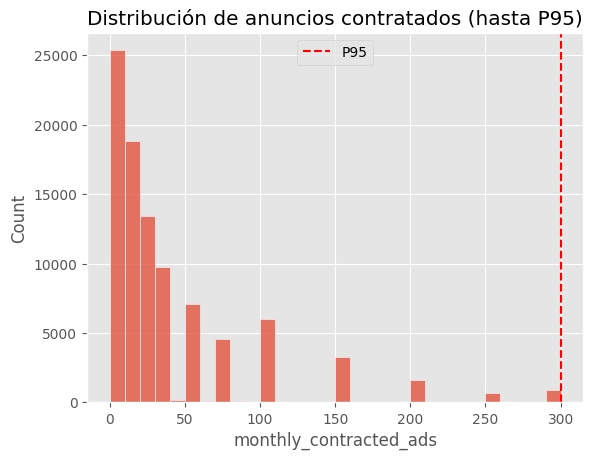

In [41]:
p95 = df_fct["monthly_contracted_ads"].quantile(0.95)

sns.histplot(
    df_fct[df_fct['monthly_contracted_ads'] <= p95]['monthly_contracted_ads'],
    bins=30
)

plt.axvline(p95, color='red', linestyle='--', label='P95')
plt.legend()
plt.title("Distribución de anuncios contratados (hasta P95)")
plt.show()

- Distribución del tamaño de los clientes según nº de meses contratados. Para visualizarlo mejor, se muestra el percentil 95 ya que la distribución tiene cola larga hacia la derecha: muchos anunciantes con pocos anuncios y pocos anunciantes con muchísimos anuncios
- La mitad tiene contratados 20 anuncios o menos

In [42]:
df_fct.groupby("period_int")["advertiser_zrive_id"].nunique().mean()

np.float64(3338.862068965517)

In [43]:
# Clientes únicos
print(f"Clientes únicos: {df_fct['advertiser_zrive_id'].nunique():}")
#media de clientes por meses
clientes_por_mes = (
    df_fct
        .groupby("period_int")["advertiser_zrive_id"]
        .nunique()
)
print(f"Análisis de clientes por mes")
clientes_por_mes.describe()


Clientes únicos: 6968
Análisis de clientes por mes


count      29.000000
mean     3338.862069
std       100.918186
min      3144.000000
25%      3258.000000
50%      3346.000000
75%      3413.000000
max      3542.000000
Name: advertiser_zrive_id, dtype: float64

- La mayoría de clientes son pequeños o medianos: lo normal es contratar unos 20 anuncios y publicar alrededor de 12.  
- Los datos están muy descompensados, con unos pocos clientes muy grandes que suben la media, por lo que los percentiles representan mejor la realidad que la media.  
- Aunque hay casi 7.000 clientes distintos en total, de media hay unos 3.340 clientes únicos activos, lo que muestra bastante rotación de clientes en el tiempo.  
- El recorrido de los anuncios es claro (se muestran, se visitan y luego generan leads), pero los leads no son muchos, así que el valor del servicio está más en el rendimiento que en el volumen.

><h4>Creación columnas nuevas<h4>

In [44]:
# Lead Conversion Rate (% de visitas se convierten en leads)
df_fct["conversion_rate"] = np.where(
    df_fct["monthly_visits"] > 0,
    df_fct["monthly_leads"] / df_fct["monthly_visits"],
    np.nan
)

# Cost Per Lead (cuanto paga el cliente por cada lead generado)
df_fct["cost_per_lead"] = np.where(
    df_fct["monthly_leads"] > 0,
    df_fct["monthly_total_invoice"] / df_fct["monthly_leads"],
    np.nan
)

# Ratio de Uso (anuncios publicados vs contratados)
df_fct["usage_ratio"] = (df_fct["monthly_published_ads"]/df_fct["monthly_contracted_ads"].replace(0, np.nan))

In [45]:
df_fct["usage_ratio"].describe()

count    96484.000000
mean         0.720402
std          0.361695
min          0.000000
25%          0.500000
50%          0.800000
75%          1.000000
max          3.700000
Name: usage_ratio, dtype: float64

Distribución del ratio de uso: anuncios publicados frente a los contratados. Se comprueba que el un 25% de los df_dim tienen un ratio > 1. Como está a nivel user - mes, hacemos un groupby para ver la info a nivel usuario y ver el total de anuncios contratados y publicados

In [46]:
df_usage_ratio = (
    df_fct
    .groupby("advertiser_zrive_id")[["monthly_contracted_ads", "monthly_unique_published_ads"]]
    .sum()
    .assign(
    usage_ratio=lambda x:
        x["monthly_unique_published_ads"] / x["monthly_contracted_ads"].replace(0, np.nan) 
    )
)
df_usage_ratio

,monthly_contracted_ads,monthly_unique_published_ads,usage_ratio
advertiser_zrive_id,,,
1,375,169,0.450667
2,4350,1728,0.397241
3,105,51,0.485714
4,2990,3029,1.013043
5,1075,779,0.724651
...,...,...,...
7047,3,0,0.000000
7051,20,0,0.000000
7052,3,0,0.000000


In [47]:
df_usage_ratio["usage_ratio"].describe()

count    6956.000000
mean        0.642500
std         0.325140
min         0.000000
25%         0.429151
50%         0.709938
75%         0.889720
max         3.000000
Name: usage_ratio, dtype: float64

Sigue habiendo usuarios que tienen más anuncios publicados que contratados, puede ser un error en los datos

In [48]:
df_fct["conversion_rate"].describe(percentiles=[0.75])

count    91430.000000
mean         0.007997
std          0.080387
min          0.000000
50%          0.003727
75%          0.006829
max         18.750000
Name: conversion_rate, dtype: float64

Ratio de conversión: % de visitas que se convierten en leads
- Fuertemente sesgada hacia la derecha
- Algunos casos muestran ratio > 1, lo cual no tiene sentido

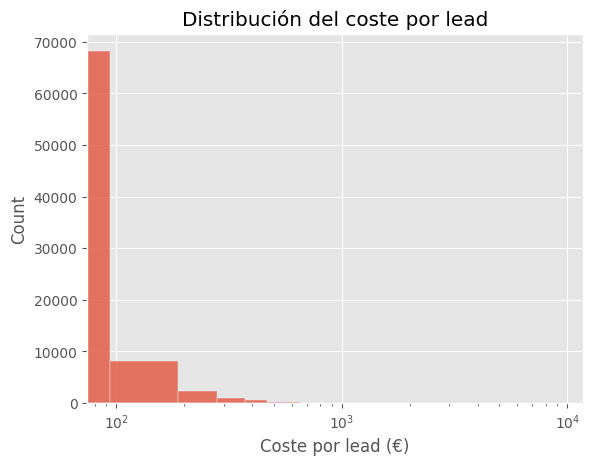

In [49]:
sns.histplot(
    df_fct["cost_per_lead"], 
    bins = 100
)
plt.xscale("log")
plt.xlabel("Coste por lead (€)")
plt.title("Distribución del coste por lead")
plt.show()

>La distribución del coste por lead está muy sesgada a la derecha; existe una cola larga de pocos clientes con costes muy elevados

In [50]:
len(set(df_fct.advertiser_zrive_id) - set(df_dim.advertiser_zrive_id))

0

Todos los df_dim en **fct** están en **dim**

In [51]:
df_master = df_fct.merge(
    df_dim,
    on="advertiser_zrive_id",
    how="left"
)
df_master.shape

(96827, 35)

In [52]:
df_master.head()

,advertiser_zrive_id,period_int,monthly_contracted_ads,monthly_published_ads,monthly_unique_published_ads,monthly_distinct_ads,monthly_oro_ads,monthly_plata_ads,monthly_destacados_ads,monthly_pepitas_ads,...,conversion_rate,cost_per_lead,usage_ratio,province_id,updated_at,advertiser_province,advertiser_group_id,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date
0,1,2023-01,75,47,47,56.0,6,6,6,0,...,0.003962,95.233333,0.626667,11,2023-06-16 09:35:01,Cádiz,NaN,2020-12-23,NaT,2023-05-31
1,2,2023-01,150,31,31,55.0,10,10,4,0,...,0.002003,73.325000,0.206667,11,2023-11-06 16:01:14,Cádiz,100.0,2020-09-25,2020-09-25,NaT
2,3,2023-01,0,0,0,NaN,0,0,0,0,...,NaN,NaN,NaN,8,2024-08-07 13:37:09,Barcelona,41.0,2024-05-06,NaT,2024-07-15
3,4,2023-01,85,79,79,86.0,3,3,1,0,...,0.004640,83.214286,0.929412,48,2023-05-03 16:37:02,Vizcaya,NaN,2022-09-30,NaT,NaT
4,6,2023-01,20,20,20,25.0,0,0,1,0,...,0.001811,21.018750,1.000000,48,2025-03-12 13:48:02,Vizcaya,NaN,2022-10-10,NaT,NaT


In [53]:
df_master.columns

Index(['advertiser_zrive_id', 'period_int', 'monthly_contracted_ads',
       'monthly_published_ads', 'monthly_unique_published_ads',
       'monthly_distinct_ads', 'monthly_oro_ads', 'monthly_plata_ads',
       'monthly_destacados_ads', 'monthly_pepitas_ads', 'monthly_shows',
       'monthly_visits', 'monthly_leads', 'monthly_total_phone_views',
       'monthly_total_calls', 'monthly_total_emails', 'monthly_total_invoice',
       'monthly_total_reference_price', 'monthly_unique_calls',
       'monthly_unique_emails', 'monthly_unique_leads', 'monthly_avg_ad_price',
       'has_active_contract', 'price_bucket', 'price_diff_pct',
       'conversion_rate', 'cost_per_lead', 'usage_ratio', 'province_id',
       'updated_at', 'advertiser_province', 'advertiser_group_id',
       'min_start_contrato_date', 'max_start_contrato_nuevo_date',
       'contrato_churn_date'],
      dtype='object')

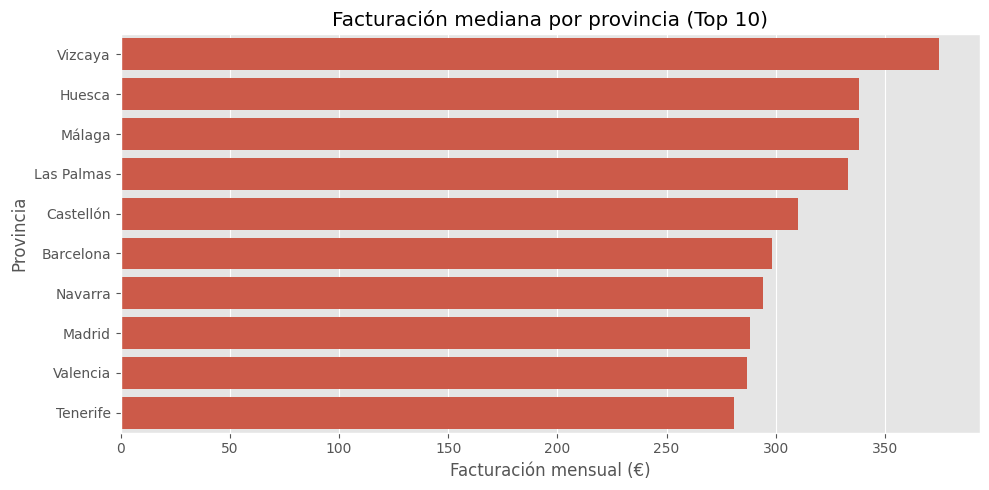

In [54]:
province_stats = (
    df_master
        .groupby('advertiser_province')['monthly_total_invoice']
        .median()
        .sort_values(ascending=False)
        .head(10)
)

plt.figure(figsize=(10, 5))
sns.barplot(
    x=province_stats.values,
    y=province_stats.index
)

plt.title('Facturación mediana por provincia (Top 10)')
plt.xlabel('Facturación mensual (€)')
plt.ylabel('Provincia')
plt.tight_layout()
plt.show()

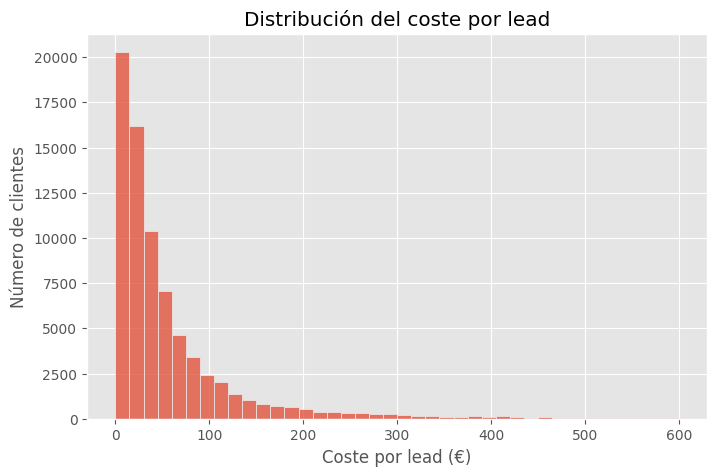

In [55]:
df_cost_plot = df_fct[
    (df_fct["cost_per_lead"] > 0) &
    (df_fct["cost_per_lead"] <= 600)
]

plt.figure(figsize=(8,5))

sns.histplot(
    df_cost_plot["cost_per_lead"],
    bins=40
)

plt.xlabel("Coste por lead (€)")
plt.ylabel("Número de clientes")
plt.title("Distribución del coste por lead")
plt.show()

<h4>CONCLUSIÓN</h4>

- El 55% de clientes (3,894 de 7,076) han solicitado baja al menos una vez
- La causa principal por la que chacer churn es "VALOR PERCIBIDO INSUFICIENTE", no ven suficiente retorno de lo que pagan
- El precio de tarifa no es realista: casi nadie lo paga y la mayoría de clientes está por debajo de 500€/mes.
- Hay diferencias claras por provincia, así que no tiene sentido un precio único para todos.
- Las métricas clave que explican el churn y deben guiar el pricing son:
     - Coste por lead

     - Ratio de conversión

     - Ratio de uso

     - Provincia (valor del tráfico)

     - Antigüedad del cliente

- Data quality: tanto en ratio de conversión como ratio de uso hay valores > 1, lo cual no tiene sentido

## Rango de fechas

Comprobamos en qué fechas tenemos datos en cada tabla

In [56]:
print("\n--- RANGO DE FECHAS ---")
print(f"df_dim  min_start_contrato_date: "
      f"{df_dim['min_start_contrato_date'].min()} "
      f"→ {df_dim['min_start_contrato_date'].max()}")
print(f"df_fct     period_int:              "
      f"{df_fct['period_int'].min()} "
      f"→ {df_fct['period_int'].max()}")
print(f"df_wd  withdrawal_creation_date: "
      f"{df_wd['withdrawal_creation_date'].min()} "
      f"→ {df_wd['withdrawal_creation_date'].max()}")


--- RANGO DE FECHAS ---
df_dim  min_start_contrato_date: 2009-10-16 00:00:00 → 2025-06-20 00:00:00
df_fct     period_int:              2023-01 → 2025-05
df_wd  withdrawal_creation_date: 2012-06-19 07:12:34 → 2025-05-30 11:29:06


- En las tablas dim y wd hay datos mucho anteriores al periodo de estudio, que comienza en 2023. Los datos que nos sobran serían aquellos de df_wd donde la fecha de baja definitiva (withdrawal_effective_date) es menor a 2023

## Análisis comportamiento advertisers

Antes de analizar el comportamiento (altas y bajas) de los advertisers, filtramos df_fct y nos quedamos únicamente con aquellos advertisers cuya fecha de inicio de contrato es ≥ 2023-01-01.

Esto lo hacemos porque la información de comportamiento solo existe a partir de esa fecha. Por tanto, si un advertiser empezó antes, no podemos asumir que 2023-01-01 sea su primer mes en la plataforma, ya que podría haber tenido actividad previa no registrada, lo que distorsionaría el análisis.

Para ello, hacemos un merge entre df_fct y df_dim para tener información sobre el comportamiento de los advertisers e información sobre sus contratos en la misma tabla

### Comprobación: ¿advertisers en df_fct están en df_dim?

In [57]:
set(df_fct["advertiser_zrive_id"].unique()).difference(set(df_dim["advertiser_zrive_id"].unique()))

set()

Sí, todos los advertisers de df_fct están en la tabla df_dim, con lo cual tenemos información sobre los contratos de todos

In [58]:
df_dim.columns

Index(['advertiser_zrive_id', 'province_id', 'updated_at',
       'advertiser_province', 'advertiser_group_id', 'min_start_contrato_date',
       'max_start_contrato_nuevo_date', 'contrato_churn_date'],
      dtype='object')

In [87]:
df_fct_dim = df_fct.merge(
    df_dim[["advertiser_zrive_id", "province_id", "advertiser_province", "advertiser_group_id", "min_start_contrato_date", "max_start_contrato_nuevo_date", "contrato_churn_date"]],
    how="left",
    on="advertiser_zrive_id"
    )
df_fct_dim 

,advertiser_zrive_id,period_int,monthly_contracted_ads,monthly_published_ads,monthly_unique_published_ads,monthly_distinct_ads,monthly_oro_ads,monthly_plata_ads,monthly_destacados_ads,monthly_pepitas_ads,...,price_diff_pct,conversion_rate,cost_per_lead,usage_ratio,province_id,advertiser_province,advertiser_group_id,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date
0,1,2023-01,75,47,47,56.0,6,6,6,0,...,-0.290686,0.003962,95.233333,0.626667,11,Cádiz,NaN,2020-12-23,NaT,2023-05-31
1,2,2023-01,150,31,31,55.0,10,10,4,0,...,-0.919496,0.002003,73.325000,0.206667,11,Cádiz,100.0,2020-09-25,2020-09-25,NaT
2,3,2023-01,0,0,0,NaN,0,0,0,0,...,NaN,NaN,NaN,NaN,8,Barcelona,41.0,2024-05-06,NaT,2024-07-15
3,4,2023-01,85,79,79,86.0,3,3,1,0,...,-0.614659,0.004640,83.214286,0.929412,48,Vizcaya,NaN,2022-09-30,NaT,NaT
4,6,2023-01,20,20,20,25.0,0,0,1,0,...,-0.346990,0.001811,21.018750,1.000000,48,Vizcaya,NaN,2022-10-10,NaT,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96822,7047,2025-05,3,0,0,NaN,0,0,2,0,...,NaN,NaN,NaN,0.000000,31,Murcia,NaN,2025-05-28,2025-05-28,NaT
96823,7051,2025-05,20,0,0,NaN,0,0,0,0,...,NaN,NaN,NaN,0.000000,37,La Rioja,NaN,2025-05-29,2025-05-29,NaT
96824,7052,2025-05,3,0,0,NaN,0,0,2,0,...,NaN,NaN,NaN,0.000000,30,Málaga,NaN,2025-05-29,2025-05-29,NaT
96825,7066,2025-05,20,20,20,29.0,3,3,7,0,...,NaN,0.003413,0.000000,1.000000,29,Madrid,NaN,2025-06-10,NaT,NaT


Eliminamos los usuarios inactivos entre 2023 - 2025

In [60]:
(
    df_fct
    .groupby("advertiser_zrive_id")["has_active_contract"]
    .sum()
    .loc[lambda x: x==0]
)

advertiser_zrive_id
7036    0
7066    0
7069    0
Name: has_active_contract, dtype: int64

In [88]:
advertisers_inactivos = [7036, 7066, 7069]
df_fct_dim = df_fct_dim[~df_fct_dim["advertiser_zrive_id"].isin(advertisers_inactivos)]

In [89]:
df_fct_dim["min_start_contrato_date"].isna().any()

np.False_

## Tipos de clientes en el periodo de estudio (2023-2025)

Entre 2023 y 2025, podemos tener clientes con diferentes comportamientos:
1) Clientes que entraron con un contrato activo: filtramos y nos quedamos con los siguientes (punto 2.)
2) Clientes que se dieron de alta una vez empezado el periodo de estudio:
    - Se dieron de baja antes del final del periodo (2025) -> tienen una fecha contrato_churn_date != NaT
    - Siguen de alta -> contrato_churn_date == NaT

In [63]:
df_fct_dim[(df_fct_dim["has_active_contract"]==True)]["period_int"].max()

Period('2025-05', 'M')

Último `period_int` del dataset en el que existe al menos un usuario activo. Todos los advertisers con un `contrato_churn_date` > 2025-05-01 se consideran censurados, es decir, activos

### 1) Clientes que entraton con un contrato activo

Estos no nos sirven, ya que no tenemos información del comportamiento en sus primeros meses. En caso de que estos mismos se den de baja y vuelvan a darse de alta pasado el 2023-01-01, sí nos valdrían ya que ahí sí tenemos información de su comportamiento en sus primeros meses del nuevo contrato.

Por definición del negocio, tenemos:
- **min_start_contrato_date**: Fecha inicial del primer contrato (antigüedad). 
- **max_start_contrato_nuevo_date**: Fecha inicial del último contrato de tipo: nuevo, en  caso de existir. Indica si un anunciante se dio de baja y retornó a la plataforma. 

Por tanto, para este filtro usaremos como criterio si su **min_start_contrato_date** es >= 2023-01-01, así nos aseguramos que al menos el primer contrato empezó en el periodo de estudio


In [64]:
df_fct_dim = df_fct_dim.sort_values(["advertiser_zrive_id", "period_int"])
df_fct_dim = df_fct_dim[df_fct_dim["min_start_contrato_date"] >= "2023-01-01"].copy()
df_fct_dim.head()

,advertiser_zrive_id,period_int,monthly_contracted_ads,monthly_published_ads,monthly_unique_published_ads,monthly_distinct_ads,monthly_oro_ads,monthly_plata_ads,monthly_destacados_ads,monthly_pepitas_ads,...,price_diff_pct,conversion_rate,cost_per_lead,usage_ratio,province_id,advertiser_province,advertiser_group_id,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date
2,3,2023-01,0,0,0,NaN,0,0,0,0,...,NaN,NaN,NaN,NaN,8,Barcelona,41.0,2024-05-06,NaT,2024-07-15
53017,3,2024-05,35,17,17,NaN,0,0,0,0,...,NaN,0.024917,0.0,0.485714,8,Barcelona,41.0,2024-05-06,NaT,2024-07-15
56457,3,2024-06,35,17,17,NaN,0,0,0,0,...,NaN,0.000000,NaN,0.485714,8,Barcelona,41.0,2024-05-06,NaT,2024-07-15
59986,3,2024-07,35,17,17,NaN,0,0,0,0,...,NaN,0.000000,NaN,0.485714,8,Barcelona,41.0,2024-05-06,NaT,2024-07-15
59988,5,2024-07,100,0,0,NaN,30,5,2,0,...,NaN,NaN,NaN,0.000000,48,Vizcaya,193.0,2024-07-30,2024-09-30,NaT


In [65]:
df_fct_dim["advertiser_zrive_id"].nunique()

3657

Tras aplicar este filtro, nos quedamos con 3657 advertisers cuyo primer contrato (min_start_contrato_date) empieza ≥ 2023-01-01. De esta forma, tenemos el comportamiento completo de todos los advertisers desde su entrada en la plataforma, evitando así sesgos derivados de actividad previa no registrada.

Text(0.5, 1.0, 'Distribución usuarios activos a día de hoy')

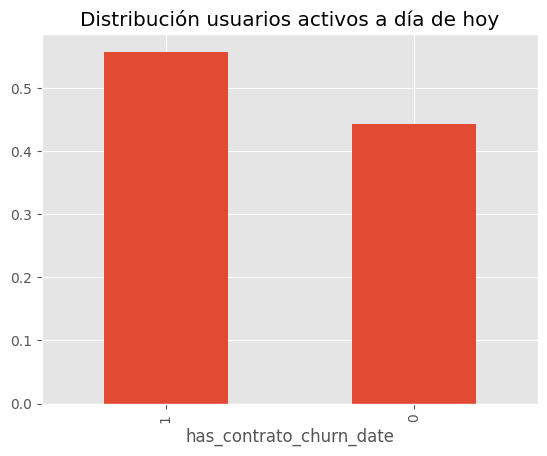

In [66]:
# Obtenemos los advertisers que tienen al menos una fecha de churn
is_churned_advertiser = (
    df_fct_dim
    .groupby("advertiser_zrive_id")["contrato_churn_date"]
    .apply(lambda x: x.notna().any())
    .astype(int)
    .rename("has_contrato_churn_date")
)
is_churned_advertiser.value_counts(normalize=True).plot(kind='bar')

plt.title("Distribución usuarios activos a día de hoy")

Esta gráfica representa la proporción de usuarios que no tienen una `contrato_churn_date` (NaT) son aquellos que no han abandonado la plataforma durante el periodo de estudio, por lo que se consideran activos/censurados
- 0: no tiene contrato_churn_date -> advertiser activo/censurado
- 1: tiene al menos una contrato_churn_date -> churneó antes de 2025

No obstante, este análisis está incompleto, ya que puede darse el caso que un usuario haya tenido un contrato que haya comenzado y finalizado entre 2023-2025 y luego tenga un nuevo contrato a posteriori pero también entre 2023-2025. 
Ej: un usuario puede hacer:
- Contrato A: empieza en 2023 -> termina en 2024 
- Contrato B: empieza en 2024 -> sigue activo en 2025 

Por tanto, lo siguiente será ver, de aquellos que han churneado alguna vez, si en realidad han tenido un 2º contrato que sigue activo a día de hoy (2025), es decir, si tienen algún `contrato_churn_date == NaT`

In [67]:
df_check = (
    df_fct_dim
    .groupby("advertiser_zrive_id")["contrato_churn_date"]
    .apply(lambda x: int(x.notna().any() and x.isna().any())) # True si tiene tiene algún NaT y algún notNaT
    .rename("churn_and_active")
)

(df_check > 0).any()

np.False_

### Bajas (has_active_contract: 1 → 0)

A continuación analizamos los usuarios cuyo has_active_contract pasa de 1 a 0 en el periodo de estudio, es decir, dejan de tener contrato activo

In [68]:
# Filtro: nos quedamos con los advertisers que han pasado de 1 a 0, es decir, que se dan de baja

df_fct_dim = (
    df_fct_dim
    .sort_values(["advertiser_zrive_id", "period_int"])
    .assign(
        prev_has_active_contract=lambda df: df.groupby("advertiser_zrive_id")["has_active_contract"].shift(1) # groupby para que el shift se haga a nivel usuario, no a nivel dataset entero
    )
)

changes_1_0 = (
    df_fct_dim
    .loc[lambda df: (df["has_active_contract"] == 0) & (df["prev_has_active_contract"] == 1)]
)

changes_1_0_ids = changes_1_0["advertiser_zrive_id"].unique()

print(f"Nº de advertisers con al menos 1 baja en el periodo de estudio: {len(changes_1_0_ids)}")
print(f"Porcentaje de advertisers con al menos 1 baja en el periodo de estudio: {(len(changes_1_0_ids)/df_fct_dim.advertiser_zrive_id.nunique()):.2f}")

Nº de advertisers con al menos 1 baja en el periodo de estudio: 440
Porcentaje de advertisers con al menos 1 baja en el periodo de estudio: 0.12


In [69]:
advertisers_con_multiples_bajas = (
    changes_1_0
    .groupby("advertiser_zrive_id")
    .size()
    .loc[lambda x: x>=2]
    .reset_index(name="n_bajas")
)
print(f"Nº advertisers con 2 o más bajas: {len(advertisers_con_multiples_bajas)}")
advertisers_con_multiples_bajas

Nº advertisers con 2 o más bajas: 5


,advertiser_zrive_id,n_bajas
0,1923,2
1,2406,2
2,4912,2
3,4913,2
4,4914,2


Estos usuarios se han dado de baja en 2 ocasiones entre 2023-2025. 

### Altas (has_active_contract: 0 → 1)

In [70]:
# Filtro: nos quedamos con los advertisers que han pasado de 1 a 0, es decir, que se dan de baja

changes_0_1 = (
    df_fct_dim
    .loc[lambda df: (df["has_active_contract"] == 1) & (df["prev_has_active_contract"] == 0)]
)

changes_0_1_ids = changes_0_1["advertiser_zrive_id"].unique()

print(f"Nº de advertisers con al menos 1 alta en el periodo de estudio: {len(changes_0_1_ids)}")
print(f"Porcentaje de advertisers con al menos 1 alta en el periodo de estudio: {(len(changes_0_1_ids)/df_fct_dim.advertiser_zrive_id.nunique()):.2f}")

Nº de advertisers con al menos 1 alta en el periodo de estudio: 217
Porcentaje de advertisers con al menos 1 alta en el periodo de estudio: 0.06


In [71]:
changes_0_1_ids

array([   3,   41,   48,   49,   76,  261,  296,  699,  792,  808,  921,
       1044, 1068, 1087, 1089, 1193, 1257, 1278, 1344, 1355, 1386, 1393,
       1445, 1496, 1604, 1630, 1691, 1704, 1723, 1781, 1830, 1863, 1923,
       2087, 2229, 2236, 2289, 2377, 2381, 2406, 2423, 2436, 2475, 2525,
       2753, 2901, 2902, 3014, 3112, 3205, 3245, 3524, 3539, 3798, 3805,
       3811, 3954, 4002, 4037, 4109, 4183, 4281, 4284, 4340, 4345, 4360,
       4412, 4484, 4500, 4549, 4726, 4745, 4755, 4791, 4800, 4815, 4819,
       4826, 4835, 4852, 4880, 4904, 4912, 4913, 4914, 4926, 4928, 4945,
       4954, 4961, 4978, 4985, 5003, 5026, 5050, 5147, 5160, 5176, 5180,
       5196, 5205, 5206, 5223, 5228, 5233, 5235, 5253, 5282, 5296, 5300,
       5310, 5333, 5341, 5364, 5365, 5381, 5393, 5403, 5413, 5448, 5453,
       5490, 5494, 5504, 5518, 5526, 5528, 5534, 5538, 5539, 5566, 5573,
       5611, 5620, 5621, 5644, 5646, 5677, 5690, 5707, 5721, 5723, 5738,
       5743, 5750, 5755, 5756, 5792, 5820, 5884, 59

In [72]:
df_fct_dim[df_fct_dim["advertiser_zrive_id"]==5820]

,advertiser_zrive_id,period_int,monthly_contracted_ads,monthly_published_ads,monthly_unique_published_ads,monthly_distinct_ads,monthly_oro_ads,monthly_plata_ads,monthly_destacados_ads,monthly_pepitas_ads,...,conversion_rate,cost_per_lead,usage_ratio,province_id,advertiser_province,advertiser_group_id,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date,prev_has_active_contract
3502,5820,2023-01,35,34,34,40.0,0,0,0,0,...,0.001030,0.000000,0.971429,48,Vizcaya,NaN,2024-02-13,NaT,NaT,NaN
6862,5820,2023-02,35,35,35,36.0,0,0,0,0,...,0.001192,0.000000,1.000000,48,Vizcaya,NaN,2024-02-13,NaT,NaT,False
10283,5820,2023-03,35,33,33,40.0,0,0,0,0,...,0.001432,0.000000,0.942857,48,Vizcaya,NaN,2024-02-13,NaT,NaT,False
13700,5820,2023-04,41,31,31,38.0,0,1,1,0,...,0.000928,0.000000,0.756098,48,Vizcaya,NaN,2024-02-13,NaT,NaT,False
17089,5820,2023-05,41,39,39,44.0,0,1,1,0,...,0.001051,0.000000,0.951220,48,Vizcaya,NaN,2024-02-13,NaT,NaT,False
20449,5820,2023-06,41,40,40,48.0,0,1,1,0,...,0.001074,0.000000,0.975610,48,Vizcaya,NaN,2024-02-13,NaT,NaT,False
23886,5820,2023-07,41,39,39,43.0,0,1,1,0,...,0.001404,0.000000,0.951220,48,Vizcaya,NaN,2024-02-13,NaT,NaT,False
27111,5820,2023-08,41,39,39,42.0,0,1,1,0,...,0.001157,0.000000,0.951220,48,Vizcaya,NaN,2024-02-13,NaT,NaT,False
30310,5820,2023-09,41,40,40,46.0,0,1,1,0,...,0.000555,0.000000,0.975610,48,Vizcaya,NaN,2024-02-13,NaT,NaT,False
33452,5820,2023-10,41,43,43,49.0,0,1,1,0,...,0.001700,0.000000,1.048780,48,Vizcaya,NaN,2024-02-13,NaT,NaT,False


In [73]:
df_fct_dim[df_fct_dim["contrato_churn_date"]> "2025-05-01"]

,advertiser_zrive_id,period_int,monthly_contracted_ads,monthly_published_ads,monthly_unique_published_ads,monthly_distinct_ads,monthly_oro_ads,monthly_plata_ads,monthly_destacados_ads,monthly_pepitas_ads,...,conversion_rate,cost_per_lead,usage_ratio,province_id,advertiser_province,advertiser_group_id,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date,prev_has_active_contract
76706,51,2024-12,35,30,30,7.0,0,1,6,0,...,0.016029,0.000000,0.857143,8,Barcelona,NaN,2024-12-23,2024-12-23,2025-05-31,NaN
80155,51,2025-01,35,34,34,9.0,0,1,6,0,...,0.012542,0.596429,0.971429,8,Barcelona,NaN,2024-12-23,2024-12-23,2025-05-31,True
83556,51,2025-02,35,33,33,8.0,0,1,6,0,...,0.008417,0.726087,0.942857,8,Barcelona,NaN,2024-12-23,2024-12-23,2025-05-31,True
86969,51,2025-03,35,33,33,9.0,0,1,6,0,...,0.012400,13.380556,0.942857,8,Barcelona,NaN,2024-12-23,2024-12-23,2025-05-31,True
90313,51,2025-04,35,34,34,8.0,0,1,6,0,...,0.014973,22.938095,0.971429,8,Barcelona,NaN,2024-12-23,2024-12-23,2025-05-31,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93437,6872,2025-04,10,0,0,NaN,0,0,0,0,...,NaN,NaN,0.000000,23,Huesca,NaN,2025-02-21,NaT,2025-05-31,True
96656,6872,2025-05,10,0,0,NaN,0,0,0,0,...,NaN,NaN,0.000000,23,Huesca,NaN,2025-02-21,NaT,2025-05-31,True
90250,6931,2025-03,10,0,0,NaN,0,0,0,0,...,NaN,NaN,0.000000,3,Alicante,NaN,2025-03-28,2025-03-28,2025-05-31,NaN
93491,6931,2025-04,10,0,0,NaN,0,0,0,0,...,NaN,NaN,0.000000,3,Alicante,NaN,2025-03-28,2025-03-28,2025-05-31,True


In [74]:
advertisers_con_multiples_altas = (
    changes_0_1
    .groupby("advertiser_zrive_id")
    .size()
    .loc[lambda x: x>=2]
    .reset_index(name="n_altas")
)
print(f"Nº advertisers con 2 o más altas: {len(advertisers_con_multiples_altas)}")
advertisers_con_multiples_altas

Nº advertisers con 2 o más altas: 3


,advertiser_zrive_id,n_altas
0,1087,2
1,1604,2
2,1781,2


In [75]:
df_fct_dim[df_fct_dim["advertiser_zrive_id"]==1087]

,advertiser_zrive_id,period_int,monthly_contracted_ads,monthly_published_ads,monthly_unique_published_ads,monthly_distinct_ads,monthly_oro_ads,monthly_plata_ads,monthly_destacados_ads,monthly_pepitas_ads,...,conversion_rate,cost_per_lead,usage_ratio,province_id,advertiser_province,advertiser_group_id,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date,prev_has_active_contract
770,1087,2023-01,75,75,75,91.0,6,6,2,0,...,0.002471,0.000000,1.000000,3,Alicante,154.0,2023-04-19,NaT,2024-03-31,NaN
4261,1087,2023-02,75,75,75,96.0,6,6,2,0,...,0.002818,0.000000,1.000000,3,Alicante,154.0,2023-04-19,NaT,2024-03-31,False
7620,1087,2023-03,75,75,75,112.0,6,6,2,0,...,0.009040,0.000000,1.000000,3,Alicante,154.0,2023-04-19,NaT,2024-03-31,False
11027,1087,2023-04,75,75,75,329.0,6,6,2,0,...,0.003367,485.135714,1.000000,3,Alicante,154.0,2023-04-19,NaT,2024-03-31,False
14441,1087,2023-05,75,150,150,237.0,6,6,2,0,...,0.002043,212.250000,2.000000,3,Alicante,154.0,2023-04-19,NaT,2024-03-31,True
17836,1087,2023-06,75,150,150,217.0,6,6,2,0,...,0.002280,339.600000,2.000000,3,Alicante,154.0,2023-04-19,NaT,2024-03-31,True
21208,1087,2023-07,75,150,150,227.0,6,6,2,0,...,0.003216,242.571429,2.000000,3,Alicante,154.0,2023-04-19,NaT,2024-03-31,True
24621,1087,2023-08,75,75,75,191.0,6,6,2,0,...,0.004374,283.000000,1.000000,3,Alicante,154.0,2023-04-19,NaT,2024-03-31,True
27834,1087,2023-09,75,75,75,183.0,6,6,2,0,...,0.003928,283.000000,1.000000,3,Alicante,154.0,2023-04-19,NaT,2024-03-31,True
31024,1087,2023-10,75,75,75,112.0,6,6,2,0,...,0.002478,0.000000,1.000000,3,Alicante,154.0,2023-04-19,NaT,2024-03-31,True


In [94]:
df_fct_dim[df_fct_dim["advertiser_zrive_id"]==2087]["has_active_contract"]

31593     True
34762     True
47575     True
50878     True
64547     True
67870     True
74520     True
77849    False
88111     True
91426     True
Name: has_active_contract, dtype: bool

In [77]:
advertisers_que_no_vuelven = set(changes_1_0_ids).difference(set(changes_0_1_ids))
pct_advertisers_que_no_vuelven = len(advertisers_que_no_vuelven)/df_fct["advertiser_zrive_id"].nunique()
print(f"Nº de advertisers que se dan de baja y no vuelven: {len(advertisers_que_no_vuelven)}")
print(f"Esto representa un {pct_advertisers_que_no_vuelven*100:.2f}% del total")

Nº de advertisers que se dan de baja y no vuelven: 370
Esto representa un 5.31% del total


In [78]:
df_fct["advertiser_zrive_id"].nunique()

6968

De los 6968 advertisers

- 440 se dan de baja al menos 1 vez enre 2023 y 2025, de los cuales:
    - 370 se dan de baja definitiva (es decir, no vuelven) 
    - 5 se dan de baja en más de 1 ocasión (es decir, se dan de baja y de alta varias veces)
- 217 se dan de alta al menos 1 vez
    - 3 se dan de alta en mas de 1 ocasión


## Análisis a nivel **contrato**

El problema de negocio radica en encontrar un precio estable según el comportamiento del advertiser, el cual siempre está asociado a un contrato único. Por ello, la unidad de análisis debe ser el contrato y no el advertiser, ya que un mismo advertiser puede tener varios contratos y no quedarían correctamente representados al hacer la agregación de los datos a nivel advertiser. Por tanto, definimos una nueva columna `contract_id` para identificar los contratos. 

Antes de nada, creamos `df_contract`, una copia de `df_fct_dim` pero con las columnas relevantes para el análisis

In [79]:
df_fct_dim.columns

Index(['advertiser_zrive_id', 'period_int', 'monthly_contracted_ads',
       'monthly_published_ads', 'monthly_unique_published_ads',
       'monthly_distinct_ads', 'monthly_oro_ads', 'monthly_plata_ads',
       'monthly_destacados_ads', 'monthly_pepitas_ads', 'monthly_shows',
       'monthly_visits', 'monthly_leads', 'monthly_total_phone_views',
       'monthly_total_calls', 'monthly_total_emails', 'monthly_total_invoice',
       'monthly_total_reference_price', 'monthly_unique_calls',
       'monthly_unique_emails', 'monthly_unique_leads', 'monthly_avg_ad_price',
       'has_active_contract', 'price_bucket', 'price_diff_pct',
       'conversion_rate', 'cost_per_lead', 'usage_ratio', 'province_id',
       'advertiser_province', 'advertiser_group_id', 'min_start_contrato_date',
       'max_start_contrato_nuevo_date', 'contrato_churn_date',
       'prev_has_active_contract'],
      dtype='object')

In [80]:
contract_analysis_cols = ['advertiser_zrive_id',
       'province_id', 'advertiser_group_id', 'min_start_contrato_date',
       'max_start_contrato_nuevo_date', 'contrato_churn_date','has_active_contract', 'prev_has_active_contract', 'period_int']

df_contract = df_fct_dim[contract_analysis_cols].copy()

### Criterio contrato: ¿cómo identificamos los contratos?


Definimos un contrato como un tramo continuo de actividad de un mismo advertiser_zrive_id, donde se cumple:
- `has_active_contract == True`
- `period_int` son consecutivos a nivel mensual

Es decir:
- si dos filas activas pertenecen a meses consecutivos, forman parte del mismo contrato
- si entre dos meses activos existe un salto de más de 1 mes, se considera que comienza un nuevo contrato
- si un mes pasa de `has_active_contract == False` a `True`, se considera también el inicio de un nuevo contrato

#### 1) Calculamos la diferencia mensual entre `period_int` y su valor previo

In [81]:
df_contract["prev_period_int"] = df_contract.groupby("advertiser_zrive_id")["period_int"].shift(1)
df_contract["month_diff"] = np.where(
    df_contract["prev_period_int"].notna(),
    df_contract["period_int"].astype("int64") - df_contract["prev_period_int"].astype("int64"),
    np.nan
)


#### 2) Aplicamos la lógica:
Un contrato empieza si:
- `has_active_contract == True`
- `prev_has_active_contract == False` (es decir, pasa de False a True, luego comienza un contrato) ó bien `month_diff > 1` (es decir, si la fila anterior pertenece a un contrato activo pero de un periodo anterior a 1 mes)

In [82]:
df_contract["new_contract_start"] = (
    df_contract["has_active_contract"] &
    (
        (df_contract["prev_has_active_contract"] == False) | 
        (df_contract["month_diff"] > 1)
    )
)

In [83]:
df_contract[df_contract["prev_period_int"].isna()].loc[df_contract["advertiser_zrive_id"]==32]

,advertiser_zrive_id,province_id,advertiser_group_id,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date,has_active_contract,prev_has_active_contract,period_int,prev_period_int,month_diff,new_contract_start
70057,32,11,NaN,2024-10-15,2024-10-15,NaT,True,NaN,2024-10,NaT,NaN,False


#### 3) Asignamos el ID de contrato

Finalmente, asignamos un ID de contrato en las filas donde `has_active_contract == True`, ya que solo los periodos activos forman parte de un contrato. Para ello, combinamos el ``advertiser_zrive_id`` con el acumulado de la variable ``new_contract_start``, de modo que cada nuevo inicio detectado genera un identificador distinto dentro de un mismo advertiser. Así, cada tramo continuo de actividad queda asociado a un contrato único.

In [84]:
df_contract["contract_id"] = (
    df_contract["advertiser_zrive_id"].astype(str)
    + "_"
    + df_contract
    .groupby("advertiser_zrive_id")["new_contract_start"]
    .cumsum()
    .astype(str)
).where(df_contract["has_active_contract"], np.nan)

df_contract[df_contract["advertiser_zrive_id"]==1781]

,advertiser_zrive_id,province_id,advertiser_group_id,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date,has_active_contract,prev_has_active_contract,period_int,prev_period_int,month_diff,new_contract_start,contract_id
1272,1781,46,154.0,2023-04-19,NaT,NaT,False,NaN,2023-01,NaT,NaN,False,NaN
4726,1781,46,154.0,2023-04-19,NaT,NaT,False,False,2023-02,2023-01,1.0,False,NaN
8088,1781,46,154.0,2023-04-19,NaT,NaT,False,False,2023-03,2023-02,1.0,False,NaN
11485,1781,46,154.0,2023-04-19,NaT,NaT,True,False,2023-04,2023-03,1.0,True,1781_1
14897,1781,46,154.0,2023-04-19,NaT,NaT,True,True,2023-05,2023-04,1.0,False,1781_1
18277,1781,46,154.0,2023-04-19,NaT,NaT,True,True,2023-06,2023-05,1.0,False,1781_1
21654,1781,46,154.0,2023-04-19,NaT,NaT,True,True,2023-07,2023-06,1.0,False,1781_1
25036,1781,46,154.0,2023-04-19,NaT,NaT,True,True,2023-08,2023-07,1.0,False,1781_1
28245,1781,46,154.0,2023-04-19,NaT,NaT,True,True,2023-09,2023-08,1.0,False,1781_1
31429,1781,46,154.0,2023-04-19,NaT,NaT,False,True,2023-10,2023-09,1.0,False,NaN


contract_id
1    3389
2     259
3       8
5       1
Name: count, dtype: int64



Text(0.5, 1.0, 'Distribución de advertisers según nº de contratos')

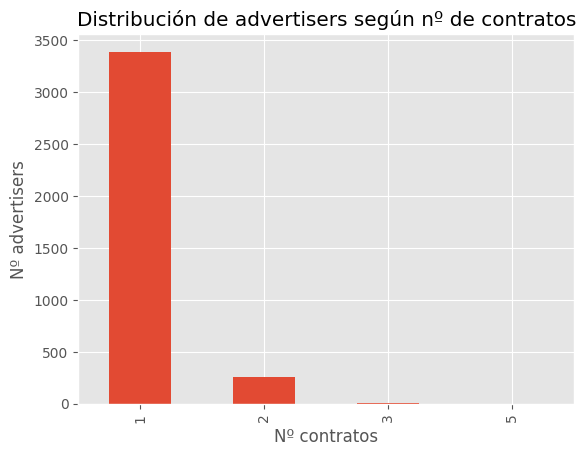

In [85]:
n_contracts_per_advertiser = (
    df_contract
    .groupby("advertiser_zrive_id")["contract_id"]
    .nunique()
)
print(n_contracts_per_advertiser.value_counts())
n_contracts_per_advertiser.value_counts().plot(kind="bar")
print()
plt.xlabel("Nº contratos")
plt.ylabel("Nº advertisers")
plt.title("Distribución de advertisers según nº de contratos")

La mayoría de advertisers tiene 1 único contrato en el periodo de estudio. Analizamos el resto de casos:

In [91]:
advertisers_con_multiples_bajas

,advertiser_zrive_id,n_bajas
0,1923,2
1,2406,2
2,4912,2
3,4913,2
4,4914,2


In [ ]:
for i in range(1,6):
    print(f'Advertisers con {i} contratos: {df_contract.groupby("advertiser_zrive_id")["contract_id"].nunique().loc[lambda x: x == i].index}')


Advertisers con 1 contratos: Index([   3,    5,    8,    9,   13,   14,   17,   19,   20,   32,
       ...
       7038, 7039, 7040, 7041, 7042, 7045, 7046, 7047, 7051, 7052],
      dtype='int64', name='advertiser_zrive_id', length=3389)
Advertisers con 2 contratos: Index([  28,   48,   49,   67,   78,  163,  169,  261,  365,  402,
       ...
       6042, 6078, 6118, 6210, 6223, 6243, 6244, 6353, 6379, 6396],
      dtype='int64', name='advertiser_zrive_id', length=259)
Advertisers con 3 contratos: Index([567, 1554, 1691, 1752, 4360, 4385, 4852, 5173], dtype='int64', name='advertiser_zrive_id')
Advertisers con 4 contratos: Index([], dtype='int64', name='advertiser_zrive_id')
Advertisers con 5 contratos: Index([2087], dtype='int64', name='advertiser_zrive_id')


In [92]:
df_contract[df_contract["advertiser_zrive_id"]==2087]

,advertiser_zrive_id,province_id,advertiser_group_id,min_start_contrato_date,max_start_contrato_nuevo_date,contrato_churn_date,has_active_contract,prev_has_active_contract,period_int,prev_period_int,month_diff,new_contract_start,contract_id
31593,2087,40,NaN,2023-10-26,2025-03-06,2025-04-07,True,NaN,2023-10,NaT,NaN,False,2087_0
34762,2087,40,NaN,2023-10-26,2025-03-06,2025-04-07,True,True,2023-11,2023-10,1.0,False,2087_0
47575,2087,40,NaN,2023-10-26,2025-03-06,2025-04-07,True,True,2024-03,2023-11,4.0,True,2087_1
50878,2087,40,NaN,2023-10-26,2025-03-06,2025-04-07,True,True,2024-04,2024-03,1.0,False,2087_1
64547,2087,40,NaN,2023-10-26,2025-03-06,2025-04-07,True,True,2024-08,2024-04,4.0,True,2087_2
67870,2087,40,NaN,2023-10-26,2025-03-06,2025-04-07,True,True,2024-09,2024-08,1.0,False,2087_2
74520,2087,40,NaN,2023-10-26,2025-03-06,2025-04-07,True,True,2024-11,2024-09,2.0,True,2087_3
77849,2087,40,NaN,2023-10-26,2025-03-06,2025-04-07,False,True,2024-12,2024-11,1.0,False,NaN
88111,2087,40,NaN,2023-10-26,2025-03-06,2025-04-07,True,False,2025-03,2024-12,3.0,True,2087_4
91426,2087,40,NaN,2023-10-26,2025-03-06,2025-04-07,True,True,2025-04,2025-03,1.0,False,2087_4


In [96]:
df_fct_dim[df_fct_dim["advertiser_zrive_id"]==2087]["has_active_contract"]

31593     True
34762     True
47575     True
50878     True
64547     True
67870     True
74520     True
77849    False
88111     True
91426     True
Name: has_active_contract, dtype: bool

In [ ]:
df_wd[df_wd["advertiser_zrive_id"]==2087]

,withdrawal_id,advertiser_zrive_id,withdrawal_status,withdrawal_type,withdrawal_creation_date,withdrawal_effective_date,withdrawal_reason,is_definitive_withdrawal
2863,21251,2087,Cerrada,TOTAL,2018-02-01 11:59:48,2018-02-01,FIN DE CONTRATO,1
3007,21743,2087,Cerrada,PARCIAL,2018-04-02 07:51:31,2018-04-01,FIN DE CONTRATO,0
3400,23140,2087,Cerrada,TOTAL,2018-10-22 11:18:34,2018-11-01,FIN DE CONTRATO,1


El advertiser 2087 probablemente podríamos eliminarlo, ya que, aún teniendo 5 contratos distintos, tienen una duración menor a 3 meses. Además, no tenemos si quiera información sobre sus withdrawals

## Comprobación FCT - WD

Escogemos un usario que esté en change_1_0_ids y lo cruzamos en la tabla wd, para ver si existe información acerca de esa baja wn df_wd

In [ ]:
changes_1_0_ids[0]

np.int64(35)

El advertiser 12 pasó de has_active_contract 1 a 0 en la fecha: 2023-07-01

In [ ]:
df_wd[df_wd["advertiser_zrive_id"] == 35]

,withdrawal_id,advertiser_zrive_id,withdrawal_status,withdrawal_type,withdrawal_creation_date,withdrawal_effective_date,withdrawal_reason,is_definitive_withdrawal
657,3404,35,Cerrada,PARCIAL,2014-05-19 15:30:32,2014-06-01,RESULTADOS,0
688,3507,35,Cerrada,TOTAL,2014-06-04 07:17:53,2014-08-01,FALTA DE PRODUCTO,1
2554,19759,35,Cerrada,PARCIAL,2017-07-11 07:39:03,2017-09-01,RESULTADOS,0
2587,19931,35,Cerrada,TOTAL,2017-08-08 10:06:08,2017-10-01,RESULTADOS,1
3495,23432,35,Cerrada,TOTAL,2018-12-11 10:30:07,2019-01-01,RAZONES ECONOMICAS,1
12970,43538,35,Cerrada,TOTAL,2023-04-13 06:46:09,2023-07-01,RAZONES ECONOMICAS,1


Efectivamente, tuvo una baja definitiva efectiva el 2023-07-01, lo que concuerda con lo anterior. Además, también se puede comprobar que el 2022-11-02 inició un proceso de baja que no fue definitivo

In [ ]:
fct_dim_advertisers_not_in_wd = set(df_fct_dim["advertiser_zrive_id"].unique()).difference(set(df_wd["advertiser_zrive_id"].unique()))
print(f"Hay un total de {len(fct_dim_advertisers_not_in_wd)} advertisers de los cuales no tenemos información de withdrawal (df_wd)")

Hay un total de 724 advertisers de los cuales no tenemos información de withdrawal (df_wd)
